### Task 2: End-to-End FinTech Text Analytics & ETL Pipeline Dashboard
**Omega Consulting Analytics Platform**

This notebook serves as the interactive presentation layer for the Task 2 analytics engine. It orchestrates the ingestion of raw reviews, applies stateless NLP transformations using a hybrid **DistilBERT/VADER** model, extracts explicit **TF-IDF keywords**, and displays tenant-isolated insights.

In [1]:
import os
import sys
import pandas as pd

notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, ".."))

if project_root not in sys.path:
    sys.path.append(project_root)
    sys.path.append(os.path.join(project_root, 'src'))

from scripts.run import execute_etl_run
from src.pipelines.aggregation_reporter import generate_analytics_report
from src.pipelines.dashboard_plots import generate_pipeline_visualizations

print(" Pipeline modules successfully imported into the notebook environment.")

 Pipeline modules successfully imported into the notebook environment.


In [2]:
execute_etl_run()

Initializing Top-Level Discoverable Analytics Execution Run...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


🔹 Processing Pipeline Segment for: CBE
------------------------------------------------------------
 [Extract] Successfully loaded 420 rows for verification review coverage.
 [TF-IDF] Top keywords discovered for CBE: ['good', 'app', 'nice', 'work', 'ok']
 [Verify Schema] Asserted output shapes: 420 rows processed.
 Target Columns Checked: ['review_id', 'review_text', 'sentiment_label', 'sentiment_score', 'identified_theme']
 [Load] Enriched CSV saved to target placeholder: c:\Users\Hello\Desktop\kaim\fintech-review-analytics\data/processed\cbe_thematic_reviews.csv

🔹 Processing Pipeline Segment for: Abyssinia
------------------------------------------------------------
 [Extract] Successfully loaded 420 rows for verification review coverage.
 [TF-IDF] Top keywords discovered for Abyssinia: ['good', 'app', 'work', 'bank', 'nice']
 [Verify Schema] Asserted output shapes: 420 rows processed.
 Target Columns Checked: ['review_id', 'review_text', 'sentiment_label', 'sentiment_score', 'iden

In [3]:
generate_analytics_report(target_dir="data/processed")


 OMEGA FINTECH ANALYTICS: AGGREGATED SENTIMENT REPORTS

Bank: CBE
-----------------------------------
 Star Rating  Mean Sentiment Confidence
           1                   0.979301
           2                   0.973418
           3                   0.942194
           4                   0.978623
           5                   0.978234
📌 Distinct Business Themes Tracked: 6

Bank: Abyssinia
-----------------------------------
 Star Rating  Mean Sentiment Confidence
           1                   0.991085
           2                   0.990108
           3                   0.956127
           4                   0.985328
           5                   0.988004
📌 Distinct Business Themes Tracked: 6

Bank: Dashen
-----------------------------------
 Star Rating  Mean Sentiment Confidence
           1                   0.995774
           2                   0.998155
           3                   0.938847
           4                   0.997088
           5                   0.99882


 Charts successfully plotted and saved to the storage layer!
Check out the new visual assets inside: ../data/plots/

 RENDERING VALIDATION PLOTS:


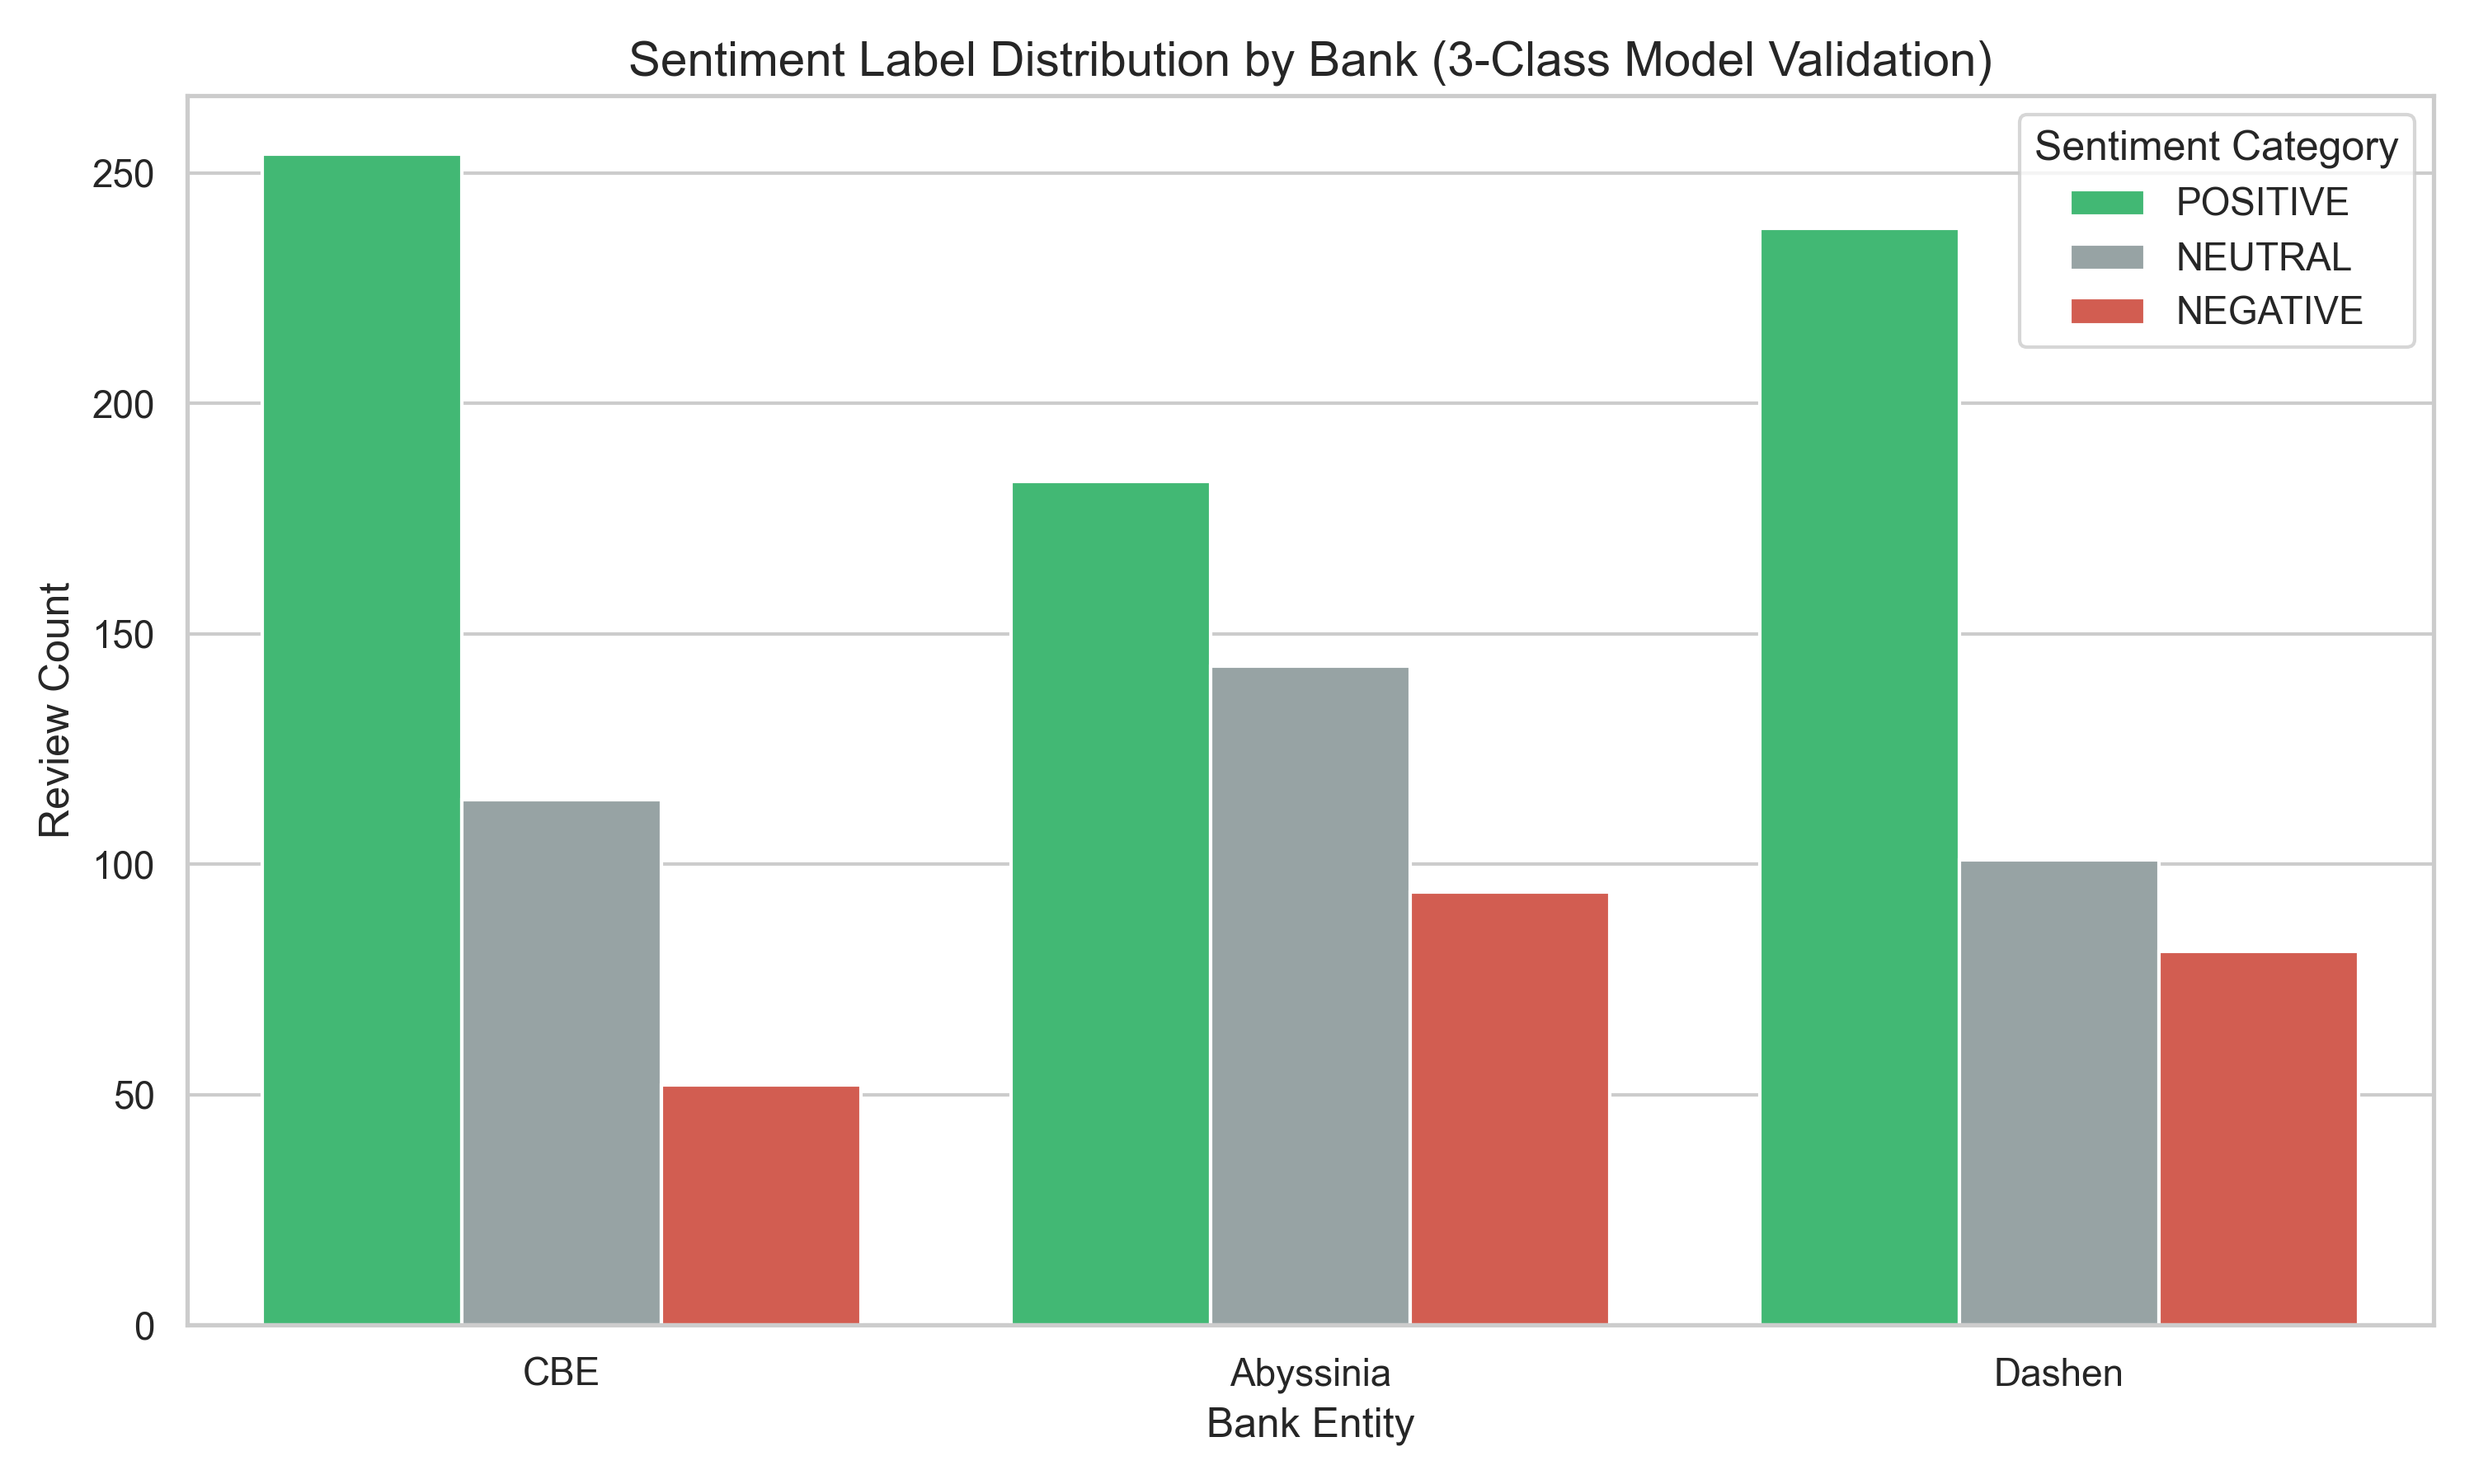

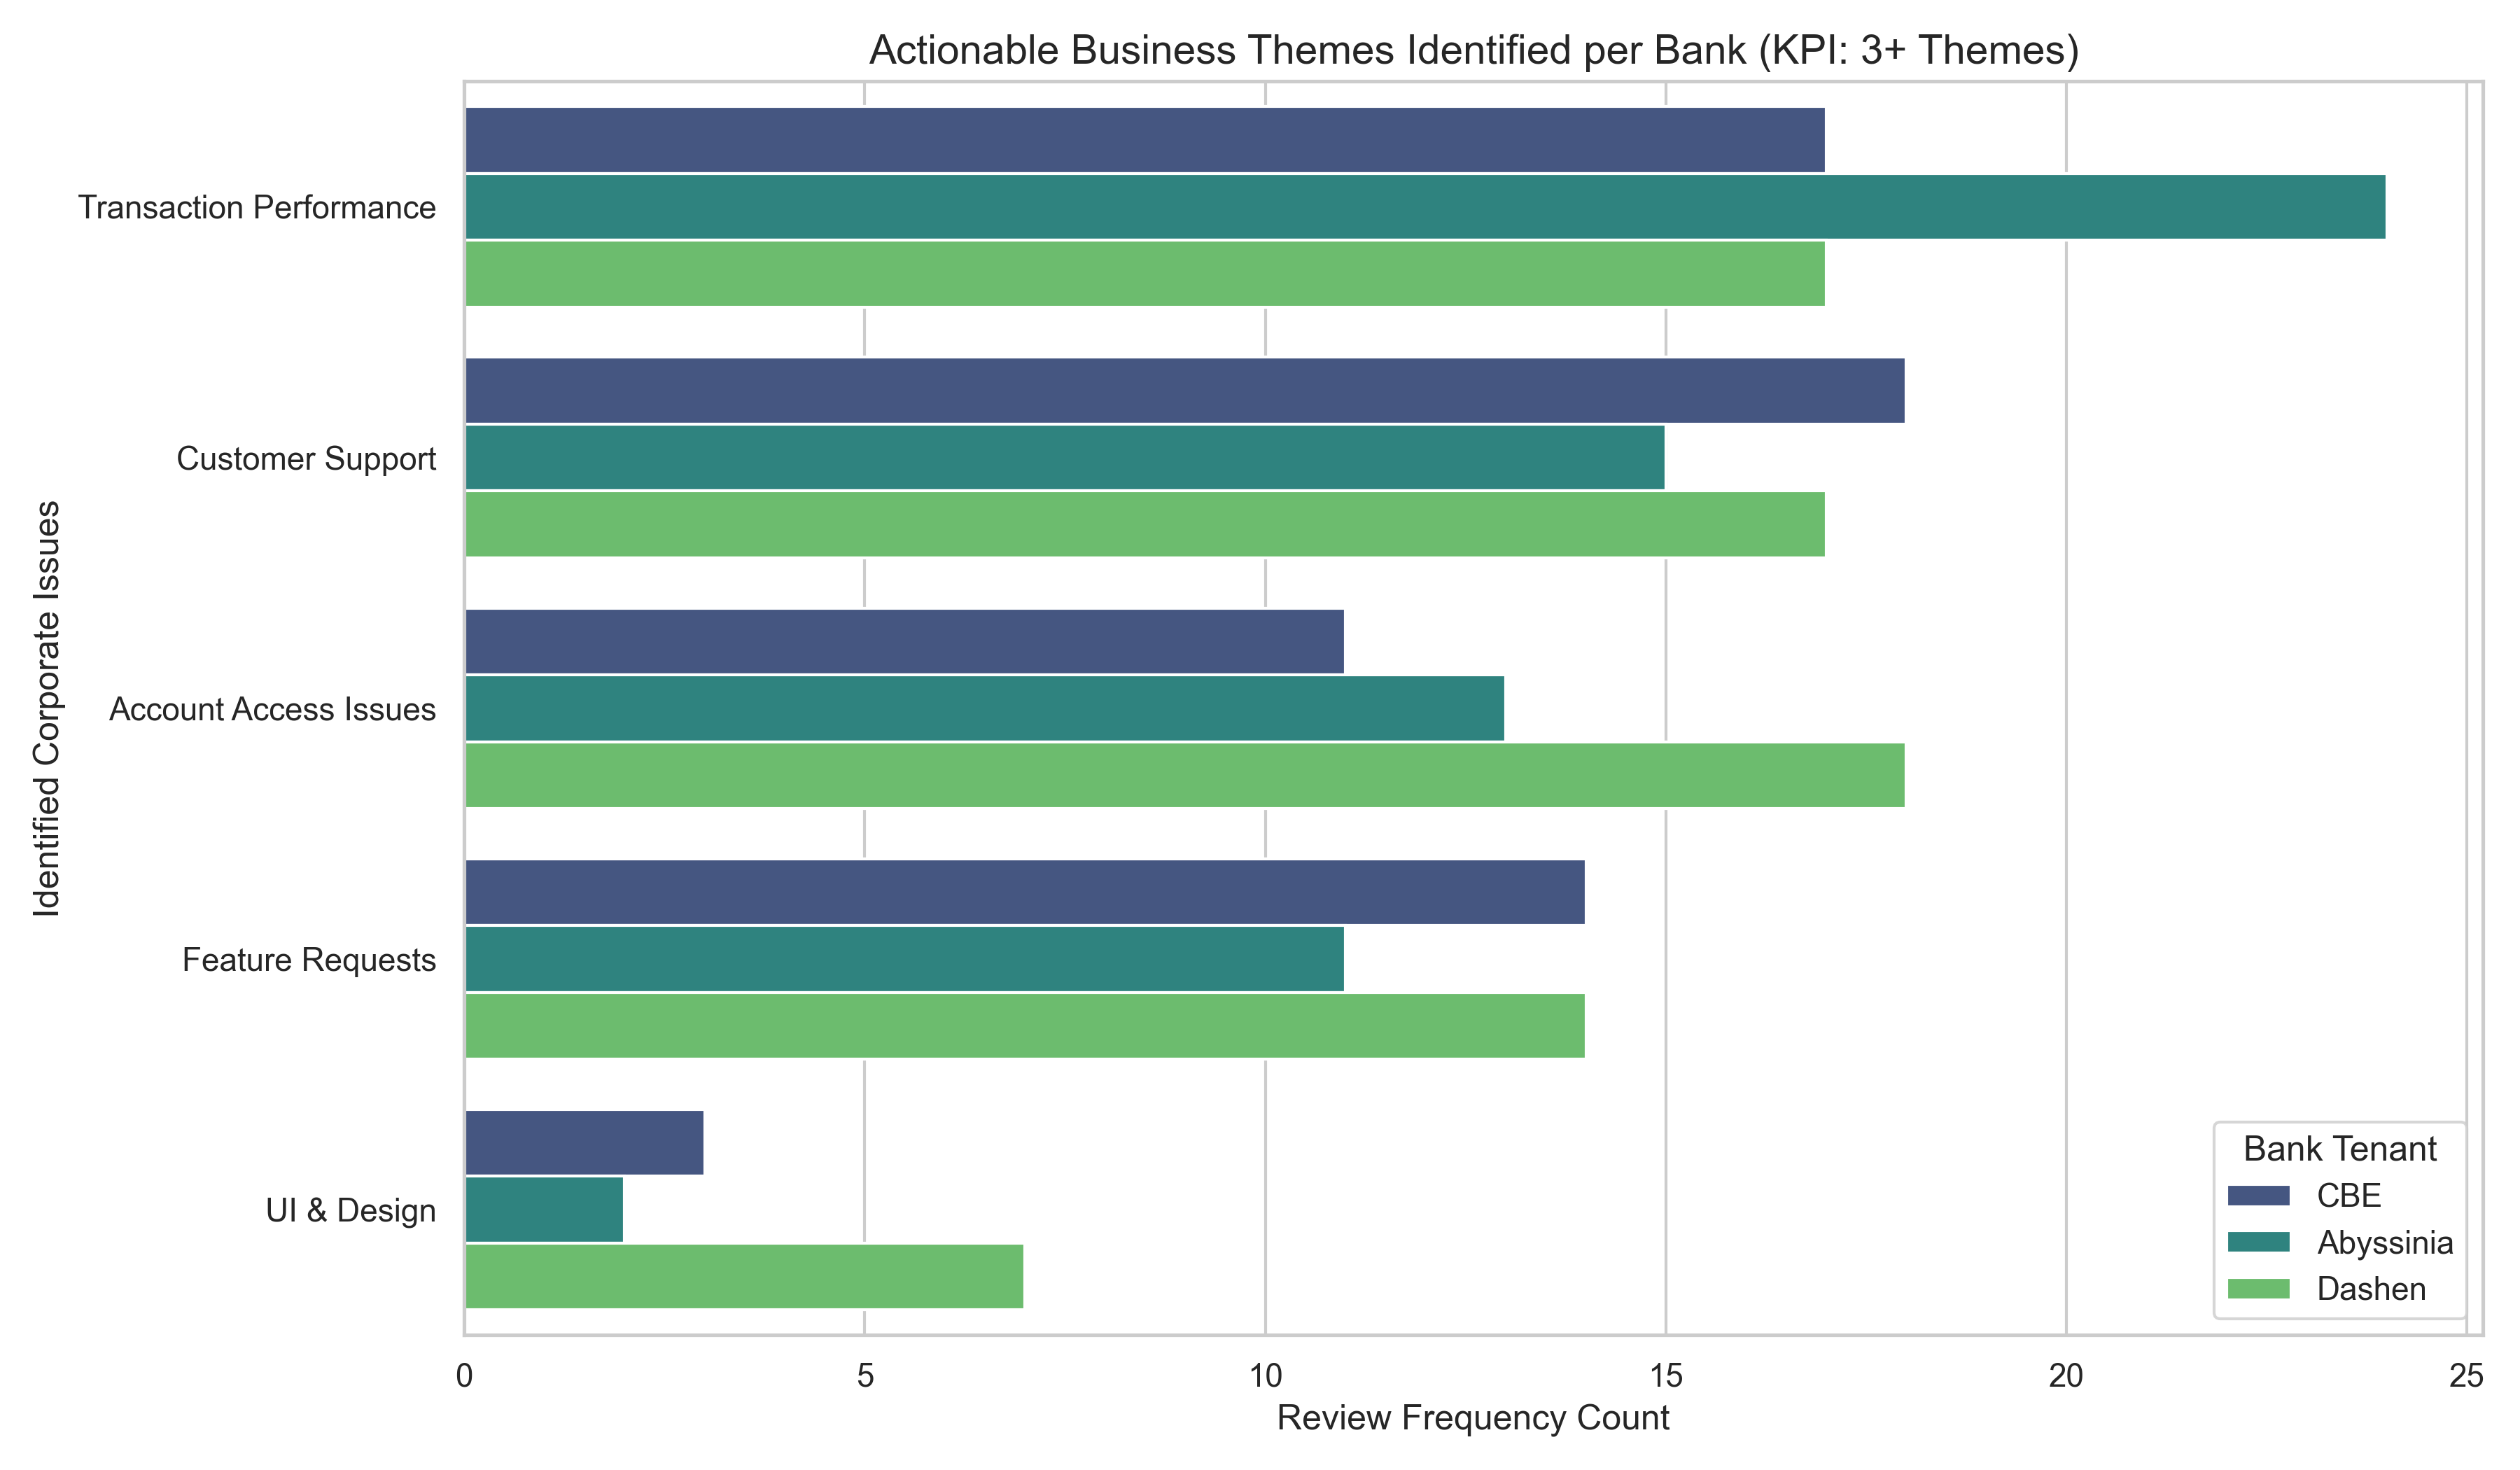

In [4]:

generate_pipeline_visualizations(processed_dir="../data/processed", output_dir="../data/plots")

from IPython.display import Image, display

print("\n RENDERING VALIDATION PLOTS:")
display(Image(filename='../data/plots/sentiment_distribution.png'))
display(Image(filename='../data/plots/thematic_breakdown.png'))